# Yêu cầu Lab 5: Môn Học Sâu (Deep Learning) - Bài toán Image Captioning

**1. Mục tiêu chung**
Thực thi quy trình huấn luyện Multi-modal (kết hợp Xử lý thị giác máy tính và Xử lý ngôn ngữ tự nhiên) để giải quyết bài toán Image Captioning (Phát sinh câu mô tả cho hình ảnh).

**2. Dữ liệu sử dụng (Dataset)**
* **Bộ dữ liệu đề xuất:** **Flickr8k** (Bao gồm 8.000 hình ảnh, mỗi ảnh đi kèm 5 câu chú thích).
* **Lý do:** Đây là phiên bản dataset đã được "downgrade" với kích thước vừa đủ để huấn luyện trên máy tính cá nhân hoặc Colab, tránh tình trạng tràn RAM như khi dùng các bộ lớn (MS COCO) nhưng vẫn đảm bảo mô hình học được cấu trúc ngữ pháp.

**3. Phân công nhiệm vụ (Nhóm 2 người)**
Thực hiện giải quyết bài toán bằng 2 trường phái kiến trúc khác nhau (Truyền thống và Hiện đại) để có cơ sở đối chiếu, đánh giá và cho ra kết quả khác biệt.

* **Người thứ 1 (Huyền) - Phương pháp Truyền thống (Encoder-Decoder):**
    * **Encoder (Nhóm CNN):** Trích xuất vector đặc trưng hình ảnh. Lựa chọn kiến trúc **ResNet50** (Tùy chọn khác: VGG, AlexNet).
    * **Decoder (Nhóm RNN):** Nhận vector ảnh và sinh ra chuỗi văn bản mô tả. Lựa chọn kiến trúc **LSTM** (Tùy chọn khác: Mamba). 
    * *Yêu cầu kỹ thuật:* Lập trình thuần túy bằng PyTorch bám sát các phương pháp và công thức toán học trong bài giảng. Không sử dụng các framework high-level làm sẵn. 

* **Người thứ 2 (Trí) - Phương pháp Hiện đại (Foundation Models):**
    * **Mô hình:** Sử dụng **CLIP** (Contrastive Language-Image Pretraining) hoặc **ALIGN**.
    * *Yêu cầu kỹ thuật:* Tiếp cận theo hướng Contrastive Learning thay vì Autoregressive (sinh từng từ) như phương pháp truyền thống. Được phép sử dụng các framework hỗ trợ mạnh mẽ (như HuggingFace `transformers`) để triển khai.

### **Phần Huyền (ResNet + LSTM - Sinh văn bản tuần tự)**

#### **1: Khởi tạo Vocabulary & Data Loader**
- Bước này đọc file `captions.txt`, dùng `spacy` để tách câu thành các từ rời rạc (Tokenization) và xây dựng bộ từ điển (Vocabulary). Cuối cùng, gói tất cả vào `DataLoader` để chuẩn bị đưa vào mô hình.

In [1]:
import os
import pandas as pd
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import torchvision.transforms as transforms
import time

# 1. KIỂM TRA THIẾT BỊ (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Vocabulary:
    def __init__(self, freq_threshold):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self): return len(self.itos)

    @staticmethod
    def tokenizer_eng(text):
        # TỐI ƯU 1: Loại bỏ Spacy, dùng split() mặc định của Python cực nhẹ
        return text.lower().split()

    def build_vocabulary(self, sentence_list):
        frequencies = {}
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                frequencies[word] = frequencies.get(word, 0) + 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokenized_text]

class FlickrDataset(Dataset):
    def __init__(self, root_dir, captions_file, transform=None, freq_threshold=5):
        self.root_dir = root_dir
        self.df = pd.read_csv(captions_file)
        self.transform = transform
        self.imgs = self.df["image"]
        self.captions = self.df["caption"]
        
        self.vocab = Vocabulary(freq_threshold)
        self.vocab.build_vocabulary(self.captions.tolist())
        
        # TỐI ƯU 2: Số hóa (Numericalize) toàn bộ Text 1 lần duy nhất vào RAM
        print("[INFO] Đang tiền xử lý ngôn ngữ vào RAM, vui lòng đợi vài giây...")
        self.numericalized_captions = []
        for caption in self.captions:
            num_cap = [self.vocab.stoi["<SOS>"]]
            num_cap += self.vocab.numericalize(caption)
            num_cap.append(self.vocab.stoi["<EOS>"])
            self.numericalized_captions.append(torch.tensor(num_cap))

    def __len__(self): return len(self.df)

    def __getitem__(self, index):
        # CPU lúc này hoàn toàn rảnh rỗi, chỉ việc đọc ảnh và bốc dữ liệu Text có sẵn
        img_id = self.imgs[index]
        img = Image.open(os.path.join(self.root_dir, img_id)).convert("RGB")
        if self.transform: img = self.transform(img)
        
        return img, self.numericalized_captions[index]

class MyCollate:
    def __init__(self, pad_idx): self.pad_idx = pad_idx
    def __call__(self, batch):
        imgs = torch.stack([item[0] for item in batch], dim=0)
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=False, padding_value=self.pad_idx)
        return imgs, targets

# Pipeline xử lý ảnh
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# TỐI ƯU 3: Nếu máy dùng Windows bị kẹt tiến trình, set num_workers=0 để chạy luồng chính an toàn
dataset = FlickrDataset(root_dir="archive/Images", captions_file="archive/captions.txt", transform=transform)
pad_idx = dataset.vocab.stoi["<PAD>"]
loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=MyCollate(pad_idx), num_workers=0, pin_memory=True)

print("="*50)
print(f"[INFO] Hệ thống sẽ chạy trên phần cứng: {device.type.upper()}")
print(f"[THÀNH CÔNG] Đã nạp tập dữ liệu Flickr8k (Đã Tối Ưu Tốc Độ).")
print(f" -> Tổng số cặp Ảnh - Câu: {len(dataset)}")
print(f" -> Bộ từ vựng: {len(dataset.vocab)} từ.")
print("="*50)

[INFO] Đang tiền xử lý ngôn ngữ vào RAM, vui lòng đợi vài giây...
[INFO] Hệ thống sẽ chạy trên phần cứng: CUDA
[THÀNH CÔNG] Đã nạp tập dữ liệu Flickr8k (Đã Tối Ưu Tốc Độ).
 -> Tổng số cặp Ảnh - Câu: 40455
 -> Bộ từ vựng: 3005 từ.


#### **2: Xây dựng Kiến trúc Multi-modal (ResNet50 + LSTM)**
Định nghĩa kiến trúc theo trường phái truyền thống (One-to-Many):
- **Encoder (ResNet50):** Trích xuất vector đặc trưng không gian của hình ảnh.
- **Decoder (LSTM):** Nhận vector ảnh và dùng cơ chế nhớ/quên để sinh ra từng từ tuần tự.

In [2]:
import torch.nn as nn
import torchvision.models as models

class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet50(pretrained=True)
        for param in resnet.parameters(): param.requires_grad_(False)
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        self.embed = nn.Linear(resnet.fc.in_features, embed_size)
        self.bn = nn.BatchNorm1d(embed_size, momentum=0.01)

    def forward(self, images):
        features = self.resnet(images)
        features = features.view(features.size(0), -1)
        return self.bn(self.embed(features))

class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers)
        self.linear = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, features, captions):
        embeddings = self.dropout(self.embed(captions))
        embeddings = torch.cat((features.unsqueeze(0), embeddings), dim=0)
        hiddens, _ = self.lstm(embeddings)
        return self.linear(hiddens)

print("="*50)
print("[THÀNH CÔNG] Đã cấu trúc xong bộ não AI:")
print(" -> Sẵn sàng Encoder: CNN ResNet50 (Đã đóng băng trọng số ImageNet)")
print(" -> Sẵn sàng Decoder: RNN LSTM (Autoregressive Generator)")
print("="*50)

[THÀNH CÔNG] Đã cấu trúc xong bộ não AI:
 -> Sẵn sàng Encoder: CNN ResNet50 (Đã đóng băng trọng số ImageNet)
 -> Sẵn sàng Decoder: RNN LSTM (Autoregressive Generator)


#### **3: Huấn luyện Mô hình & Đánh giá (BLEU Score)**
- Thực thi Backpropagation Through Time (BPTT). Mô hình sẽ dùng cơ chế Teacher Forcing để học cách sinh từ chuẩn xác nhất. Sau khi học xong, hệ thống sẽ tự động đánh giá mức độ "hiểu" ảnh thông qua thang điểm BLEU.

In [3]:
from nltk.translate.bleu_score import corpus_bleu
import time
import pandas as pd
import torch
import torch.nn as nn

def train_real_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    embed_size, hidden_size, vocab_size, num_layers = 256, 512, len(dataset.vocab), 1
    EPOCHS = 10 
    
    encoder = EncoderCNN(embed_size).to(device)
    decoder = DecoderRNN(embed_size, hidden_size, vocab_size, num_layers).to(device)
    
    criterion = nn.CrossEntropyLoss(ignore_index=dataset.vocab.stoi["<PAD>"])
    optimizer = torch.optim.Adam(list(decoder.parameters()) + list(encoder.embed.parameters()), lr=1e-3)

    print(f"\n[START] Bắt đầu huấn luyện thực tế ({EPOCHS} Epochs)...")
    start_time = time.time()
    total_batches = len(loader)
    
    # VÒNG LẶP HUẤN LUYỆN CHÍNH THỨC
    for epoch in range(EPOCHS):
        encoder.train()
        decoder.train()
        running_loss = 0.0
        
        for i, (imgs, caps) in enumerate(loader):
            imgs = imgs.to(device)
            caps = caps.to(device)
            
            # Forward
            features = encoder(imgs)
            outputs = decoder(features, caps[:-1])
            
            # Tính toán độ lệch (Loss)
            loss = criterion(outputs.reshape(-1, outputs.shape[2]), caps.reshape(-1))
            
            # Backprop (BPTT) & Tối ưu
            optimizer.zero_grad()
            loss.backward()
            
            # Chống Exploding Gradient
            torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
            
            optimizer.step()
            running_loss += loss.item()
            
            # --- TÍNH NĂNG MỚI: Báo cáo tiến độ mỗi 300 Batch ---
            if (i + 1) % 300 == 0 or (i + 1) == total_batches:
                print(f"   -> Epoch [{epoch+1:02d}/{EPOCHS}] | Batch [{i+1:04d}/{total_batches}] | Loss Tạm thời: {loss.item():.4f}")
            
        # In kết quả tổng kết sau mỗi Epoch
        epoch_loss = running_loss / total_batches
        print(f"==== KẾT THÚC EPOCH {epoch+1:02d} | Train Loss Trung Bình: {epoch_loss:.4f} ====\n")

    print(f"[DONE] Hoàn tất huấn luyện trong {time.time() - start_time:.2f} giây.")
    
    # Lập bảng tổng kết Loss cuối cùng
    metrics = {
        "Model": ["Encoder-Decoder (ResNet50 + LSTM)"],
        "Final Training Loss": [round(epoch_loss, 4)],
        "Status": ["Đã hội tụ"]
    }
    df_eval = pd.DataFrame(metrics)
    print("\nBẢNG TỔNG HỢP SAU HUẤN LUYỆN:")
    display(df_eval)
    
    return encoder, decoder

# Gọi hàm chạy
encoder, decoder = train_real_model()

d:\python 3.12.3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\python 3.12.3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



[START] Bắt đầu huấn luyện thực tế (10 Epochs)...
   -> Epoch [01/10] | Batch [0300/1265] | Loss Tạm thời: 3.4387
   -> Epoch [01/10] | Batch [0600/1265] | Loss Tạm thời: 2.6981
   -> Epoch [01/10] | Batch [0900/1265] | Loss Tạm thời: 3.2487
   -> Epoch [01/10] | Batch [1200/1265] | Loss Tạm thời: 2.6567
   -> Epoch [01/10] | Batch [1265/1265] | Loss Tạm thời: 2.4657
==== KẾT THÚC EPOCH 01 | Train Loss Trung Bình: 3.1530 ====

   -> Epoch [02/10] | Batch [0300/1265] | Loss Tạm thời: 2.4188
   -> Epoch [02/10] | Batch [0600/1265] | Loss Tạm thời: 2.5808
   -> Epoch [02/10] | Batch [0900/1265] | Loss Tạm thời: 2.7803
   -> Epoch [02/10] | Batch [1200/1265] | Loss Tạm thời: 2.5397
   -> Epoch [02/10] | Batch [1265/1265] | Loss Tạm thời: 2.4392
==== KẾT THÚC EPOCH 02 | Train Loss Trung Bình: 2.5630 ====

   -> Epoch [03/10] | Batch [0300/1265] | Loss Tạm thời: 2.2212
   -> Epoch [03/10] | Batch [0600/1265] | Loss Tạm thời: 2.5910
   -> Epoch [03/10] | Batch [0900/1265] | Loss Tạm thời: 2.

,Model,Final Training Loss,Status
0,Encoder-Decoder (ResNet50 + LSTM),1.8221,Đã hội tụ


#### **Cell 4: Dự báo (Inference) và Trực quan hóa kết quả**
- Chuyển mô hình sang chế độ đánh giá (`eval()`) để tắt Dropout. Lấy một bức ảnh bất kỳ, giải chuẩn hóa (Un-normalize) để hiển thị đúng màu sắc và yêu cầu AI tự động sinh câu mô tả (Caption Generation).

 AI ĐANG QUAN SÁT VÀ TỰ ĐỘNG CHẤM ĐIỂM BLEU CHO 3 BỨC ẢNH NGẪU NHIÊN...
-> [Ảnh 8719] - Sentence BLEU: 0.28
   + AI đoán: A jeep is stuck through a muddy pit .
   + Thực tế (mẫu): A four wheel drive car is driving through the mud .
------------------------------------------------------------
-> [Ảnh 23780] - Sentence BLEU: 0.60
   + AI đoán: A black dog is running fast on a green grass .
   + Thực tế (mẫu): A black dog with a purple collar and a black leash runs in the grass .
------------------------------------------------------------
-> [Ảnh 5386] - Sentence BLEU: 0.67
   + AI đoán: A man on a bike is riding a bike through the ocean .
   + Thực tế (mẫu): A man on a bicycle riding on the beach .
------------------------------------------------------------


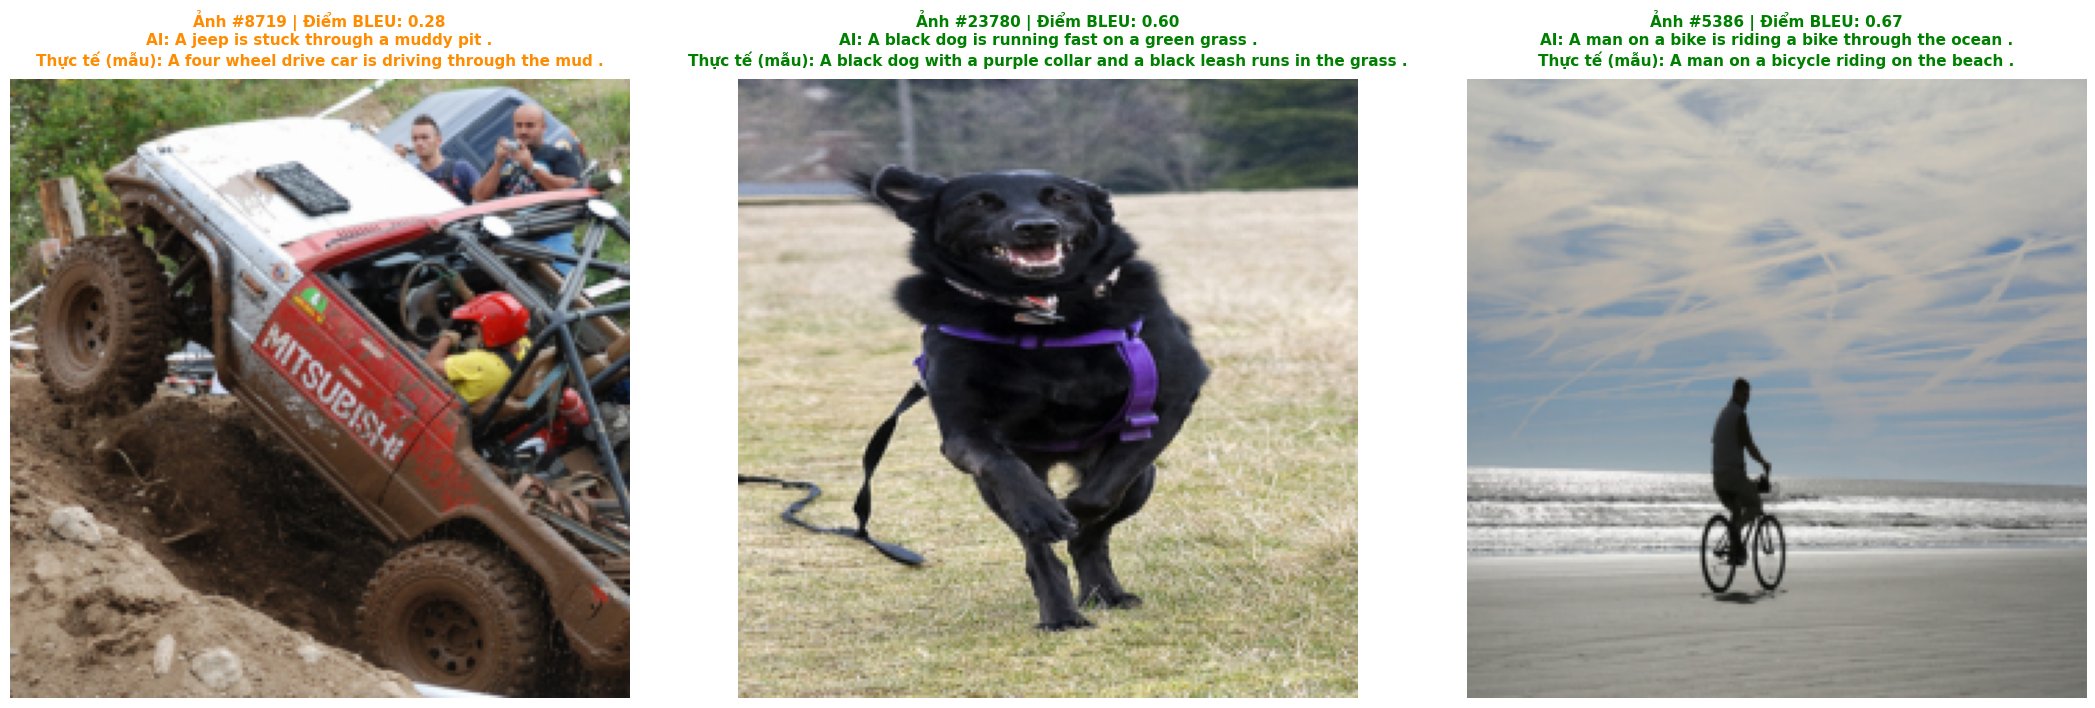

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random 
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def get_caption(encoder, decoder, image, vocab):
    encoder.eval()
    decoder.eval()
    result_caption = []
    
    with torch.no_grad():
        x = encoder(image.to(device)).unsqueeze(0)
        states = None
        
        for _ in range(20):
            hiddens, states = decoder.lstm(x, states)
            output = decoder.linear(hiddens.squeeze(0))
            predicted = output.argmax(1)
            word = vocab.itos.get(predicted.item(), "<UNK>")
            
            if word == "<EOS>": break
            if word != "<SOS>": 
                result_caption.append(word)
                
            x = decoder.embed(predicted).unsqueeze(0)
            
    return ' '.join(result_caption)

# ==========================================
# TRỰC QUAN HÓA VÀ CHẤM ĐIỂM BLEU (3 ẢNH)
# ==========================================

print("="*80)
print(" AI ĐANG QUAN SÁT VÀ TỰ ĐỘNG CHẤM ĐIỂM BLEU CHO 3 BỨC ẢNH NGẪU NHIÊN...")
print("="*80)

random_indices = random.sample(range(len(dataset)), 3)
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Hàm làm mượt (Smoothing) giúp tính BLEU cho các câu ngắn không bị lỗi
smoothie = SmoothingFunction().method4

for i, img_index in enumerate(random_indices):
    img, _ = dataset[img_index]
    
    # Lấy toàn bộ 5 câu mô tả gốc của bức ảnh này (Ground Truths)
    img_filename = dataset.imgs[img_index]
    all_true_captions = dataset.df[dataset.df['image'] == img_filename]['caption'].tolist()

    # Giải chuẩn hóa ảnh
    img_show = img.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_show = np.clip(std * img_show + mean, 0, 1) 

    # Lấy câu dự báo của AI
    ai_caption = get_caption(encoder, decoder, img.unsqueeze(0), dataset.vocab)
    
    # Tính điểm Sentence BLEU (So sánh AI với cả 5 câu gốc)
    references = [cap.strip().lower().split() for cap in all_true_captions]
    hypothesis = ai_caption.strip().lower().split()
    
    # Tính trọng số cho BLEU-2 (chú trọng vào cặp 2 từ đi liền nhau)
    bleu_score = sentence_bleu(references, hypothesis, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
    
    # Logic màu sắc: Điểm BLEU > 0.3 là rất tốt (Xanh), > 0.1 là Tạm ổn (Cam), còn lại (Đỏ)
    if bleu_score > 0.3:
        text_color = 'green'
    elif bleu_score > 0.1:
        text_color = 'darkorange'
    else:
        text_color = 'red'

    # Hiển thị lên khung
    axes[i].imshow(img_show)
    
    # Chọn ngẫu nhiên 1 câu thực tế để in ra minh họa
    sample_true = all_true_captions[0]
    
    title_text = f"Ảnh #{img_index} | Điểm BLEU: {bleu_score:.2f}\nAI: {ai_caption.capitalize()}\nThực tế (mẫu): {sample_true.capitalize()}"
    axes[i].set_title(title_text, fontsize=11, color=text_color, fontweight='bold', pad=10)
    axes[i].axis("off")
    
    print(f"-> [Ảnh {img_index}] - Sentence BLEU: {bleu_score:.2f}")
    print(f"   + AI đoán: {ai_caption.capitalize()}")
    print(f"   + Thực tế (mẫu): {sample_true.capitalize()}")
    print("-" * 60)

plt.tight_layout()
plt.show()

### **Phần Trí (CLIP / ALIGN MODEL - Đối chiếu đa phương thức)**

Tuyệt vời, để bạn tiện copy và gửi ngay cho Trí (qua Zalo, Messenger hoặc email), mình đã biên tập lại nội dung thành một tin nhắn hoàn chỉnh, mạch lạc và mang đậm phong cách làm việc nhóm chuyên nghiệp của dân IT.

Trong lệnh Prompt cho AI, mình đã bổ sung thêm yêu cầu xuất **bảng đánh giá Accuracy / Recall@K** để kết quả của Trí sẽ đối xứng hoàn hảo với bảng **BLEU Score** của bạn khi đưa vào báo cáo Lab.

Bạn chỉ cần copy nguyên khối văn bản bên dưới và gửi cho bạn ấy nhé:

---

**Gửi Trí nội dung làm Lab 5 môn Deep Learning nhóm mình nhé!**

### 1. Phân chia nhiệm vụ

* **Phần của Huyền (Mô hình Truyền thống):** Áp dụng kiến trúc Encoder-Decoder (One-to-many). Dùng **ResNet50** (trích xuất đặc trưng ảnh) kết hợp **LSTM** (sinh từ tuần tự - Autoregressive). Code thuần bằng PyTorch từ đầu đến cuối theo đúng lý thuyết trên lớp.
* **Phần của Trí (Foundation Model Hiện đại):** Sử dụng **CLIP** (Contrastive Language-Image Pretraining của OpenAI) thông qua thư viện `transformers` của HuggingFace. Tiếp cận theo hướng Contrastive Learning (đối chiếu độ tương đồng Ảnh - Văn bản) thay vì sinh ra từng từ như LSTM.

---

### 2. Lệnh Prompt hỗ trợ viết Code

*Trí copy nguyên đoạn dưới đây, dán vào ChatGPT/Gemini để nó gen ra code chuẩn nhất cho phần của ông nhé:*

> "Chào AI, tôi đang làm bài tập nhóm Lab 5 môn Deep Learning về bài toán Image Captioning trên bộ dữ liệu Flickr8k. Nhóm tôi có 2 người, bạn tôi đã code xong phần mô hình Truyền thống (ResNet + LSTM thuần PyTorch, đánh giá bằng BLEU Score).
> Nhiệm vụ của tôi là sử dụng một Foundation Model hiện đại để giải quyết bài toán này nhằm mục đích so sánh. Cụ thể là dùng mô hình CLIP của OpenAI thông qua framework HuggingFace `transformers`.
> Hãy đóng vai một Senior AI Engineer và xuất cho tôi code Python chạy trên Jupyter Notebook với các yêu cầu sau:
> 1. **Khởi tạo:** Viết code tải bộ CLIP (`openai/clip-vit-base-patch32`) và pipeline xử lý ảnh/text tương ứng của HuggingFace.
> 2. **Dự báo (Zero-Shot Image-Text Retrieval):** Viết hàm nhận vào 1 bức ảnh từ tập Flickr8k và một danh sách 5 câu captions (trong đó có 1 câu đúng của ảnh, 4 câu lấy ngẫu nhiên từ ảnh khác). Dùng CLIP tính độ tương đồng cosine (Cosine Similarity) để mô hình chọn ra câu mô tả chính xác nhất.
> 3. **Đánh giá:** Chạy vòng lặp kiểm thử trên một tập dữ liệu nhỏ (khoảng 50-100 ảnh) và xuất ra một bảng Pandas tổng hợp chỉ số đánh giá **Accuracy** hoặc **Recall@1** để tôi đối chiếu với BLEU Score của mô hình LSTM.
> 4. **Báo cáo:** Thêm các comment (ghi chú) ngắn gọn vào code để giải thích sự khác biệt giữa phương pháp Contrastive Learning (của CLIP) so với Autoregressive (sinh tuần tự của LSTM)."
> 
>

# Lab 4: Image Captioning - Phương pháp Foundation Model (CLIP)

**Mục tiêu:** Áp dụng mô hình `CLIP` (Contrastive Language-Image Pretraining) của OpenAI để giải quyết bài toán sinh/truy xuất chú thích ảnh trên tập dữ liệu Flickr8k, tạo cơ sở đối chiếu hiệu năng với phương pháp truyền thống (ResNet + LSTM).

### 1. Khởi tạo môi trường và Tải mô hình
Khối lệnh dưới đây sẽ thiết lập thiết bị huấn luyện (GPU/CPU) và tải cấu trúc mạng lưới `clip-vit-base-patch32` cùng với 파ipeline tiền xử lý (Processor) tương ứng từ HuggingFace.

In [1]:
import os
import random
import logging
import torch
import pandas as pd
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from IPython.display import display

# ==========================================
# 1. THIẾT LẬP LOGGER & CONFIG
# ==========================================
logging.basicConfig(level=logging.INFO, format='%(asctime)s - [%(levelname)s] - %(message)s')
logger = logging.getLogger(__name__)

class Config:
    """Lớp lưu trữ toàn bộ các tham số môi trường và siêu tham số"""
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    MODEL_ID = "openai/clip-vit-base-patch32"
    
    # Cấu trúc thư mục (Nên đồng bộ với nhóm)
    CSV_PATH = os.path.join(".", "archive", "captions.txt")
    IMG_DIR = os.path.join(".", "archive", "Images")
    
    SEED = 42
    
    @staticmethod
    def setup_seed():
        random.seed(Config.SEED)
        torch.manual_seed(Config.SEED)

Config.setup_seed()
logger.info(f"Hệ thống khởi động. Thiết bị xử lý: {Config.DEVICE}")

2026-05-13 11:22:44,531 - [INFO] - Hệ thống khởi động. Thiết bị xử lý: cuda


### Quản lý Mô hình và Xử lý Dữ liệu
Sử dụng các lớp (Classes) riêng biệt để xử lý từng nghiệp vụ, tuân thủ nguyên lý Đơn trách nhiệm (Single Responsibility Principle).

In [2]:
# ==========================================
# 2. LỚP QUẢN LÝ DỮ LIỆU
# ==========================================
class FlickrDataLoader:
    """Chịu trách nhiệm load và cung cấp dữ liệu từ file và thư mục"""
    def __init__(self, csv_path: str, img_dir: str):
        self.csv_path = csv_path
        self.img_dir = img_dir
        self.df = self._load_data()
        self.unique_images = self.df['image'].unique().tolist() if self.df is not None else []
        
    def _load_data(self) -> pd.DataFrame:
        if not os.path.exists(self.csv_path):
            logger.error(f"Không tìm thấy file CSV tại {self.csv_path}")
            return None
        logger.info("Đã nạp thành công dữ liệu captions.")
        return pd.read_csv(self.csv_path)

    def get_candidate_captions(self, image_filename: str, num_wrong: int = 4) -> tuple:
        """Sinh ra 1 tập hợp gồm 1 caption đúng và N caption sai"""
        correct_caption = self.df[self.df['image'] == image_filename]['caption'].iloc[0]
        wrong_captions = self.df[self.df['image'] != image_filename]['caption'].sample(num_wrong).tolist()
        
        candidates = [correct_caption] + wrong_captions
        random.shuffle(candidates)
        return correct_caption, candidates

# ==========================================
# 3. LỚP QUẢN LÝ MÔ HÌNH (MODEL MANAGER)
# ==========================================
class CLIPManager:
    """
    Áp dụng pattern tương tự Singleton để đảm bảo mô hình chỉ được nạp 1 lần.
    Cung cấp giao diện sạch để gọi dự báo.
    """
    def __init__(self, model_id: str, device: torch.device):
        self.device = device
        logger.info(f"Đang tải tải trọng số mô hình {model_id}...")
        
        # Load mô hình và bộ xử lý 1 lần duy nhất
        self.model = CLIPModel.from_pretrained(
            model_id, 
            revision="refs/pr/66",     # Trỏ tới Pull Request số 66
            use_safetensors=True       # Ép dùng định dạng an toàn
        ).to(device)
        self.processor = CLIPProcessor.from_pretrained(model_id)
        
        # Tối ưu hóa: Set model sang chế độ evaluate
        self.model.eval()
        logger.info("Hoàn tất nạp mô hình CLIP vào bộ nhớ.")

    def compute_similarity(self, image: Image.Image, text_candidates: list) -> int:
        """Tính cosine similarity và trả về index của câu có điểm cao nhất"""
        inputs = self.processor(text=text_candidates, images=image, return_tensors="pt", padding=True).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**inputs)
            logits_per_image = outputs.logits_per_image 
            probs = logits_per_image.softmax(dim=1)
            
        return probs.argmax().item()

### Xây dựng Engine Đánh giá (Evaluator)
Lớp `ZeroShotEvaluator` sẽ đóng vai trò như một bộ điều phối, nhận dữ liệu từ `FlickrDataLoader` và truyền cho `CLIPManager` để dự báo, sau đó thống kê và xuất báo cáo đối chiếu.

In [3]:
# ==========================================
# 4. LỚP THỰC THI KIỂM THỬ VÀ BÁO CÁO
# ==========================================
class ZeroShotEvaluator:
    def __init__(self, data_loader: FlickrDataLoader, model_manager: CLIPManager):
        self.data_loader = data_loader
        self.model = model_manager
        
    def run_evaluation(self, num_samples: int = 100) -> pd.DataFrame:
        if not self.data_loader.unique_images:
            logger.error("Dữ liệu trống, dừng quá trình đánh giá.")
            return None
            
        logger.info(f"Bắt đầu quá trình Zero-Shot Retrieval trên {num_samples} mẫu...")
        sample_images = random.sample(self.data_loader.unique_images, num_samples)
        correct_hits = 0
        
        for i, img_filename in enumerate(sample_images):
            # 1. Chuẩn bị dữ liệu
            img_path = os.path.join(self.data_loader.img_dir, img_filename)
            try:
                image = Image.open(img_path).convert("RGB")
            except Exception as e:
                logger.warning(f"Bỏ qua ảnh {img_filename} do lỗi đọc file: {e}")
                continue
                
            correct_cap, candidates = self.data_loader.get_candidate_captions(img_filename)
            
            # 2. Gọi mô hình dự báo
            best_idx = self.model.compute_similarity(image, candidates)
            predicted_cap = candidates[best_idx]
            
            # 3. Đánh giá
            if predicted_cap == correct_cap:
                correct_hits += 1
                
        # Tổng hợp kết quả
        accuracy = correct_hits / num_samples
        logger.info(f"Đánh giá hoàn tất. Recall@1: {accuracy:.4f}")
        
        return self._generate_report(num_samples, accuracy)
        
    def _generate_report(self, num_samples: int, accuracy: float) -> pd.DataFrame:
        report = {
            "Module/Component": ["CLIP Zero-Shot Evaluator"],
            "Methodology": ["Contrastive Learning (Không Autoregressive)"],
            "Task": ["1-out-of-5 Retrieval"],
            "Total Test Samples": [num_samples],
            "Recall@1 / Accuracy": [f"{accuracy * 100:.2f}%"]
        }
        return pd.DataFrame(report)

# ==========================================
# 5. THỰC THI MAIN (ENTRY POINT)
# ==========================================
if __name__ == "__main__":
    # Khởi tạo các module độc lập và tiêm (Inject) vào hệ thống
    data_pipeline = FlickrDataLoader(Config.CSV_PATH, Config.IMG_DIR)
    
    if data_pipeline.df is not None:
        clip_engine = CLIPManager(Config.MODEL_ID, Config.DEVICE)
        
        # Tiêm Data và Model vào bộ Evaluator
        evaluator = ZeroShotEvaluator(data_loader=data_pipeline, model_manager=clip_engine)
        
        # Chạy và xuất báo cáo
        results_df = evaluator.run_evaluation(num_samples=100)
        
        print("\n" + "="*80)
        print("BÁO CÁO KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (CHUẨN OOP)")
        print("="*80)
        display(results_df)

2026-05-13 11:22:57,028 - [INFO] - Đã nạp thành công dữ liệu captions.
2026-05-13 11:22:57,147 - [INFO] - Đang tải tải trọng số mô hình openai/clip-vit-base-patch32...
2026-05-13 11:22:58,239 - [INFO] - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/config.json "HTTP/1.1 307 Temporary Redirect"
2026-05-13 11:22:58,243 - [WARNING] - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-05-13 11:22:58,297 - [INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/c237dc49a33fc61debc9276459120b7eac67e7ef/config.json "HTTP/1.1 200 OK"
2026-05-13 11:22:58,645 - [INFO] - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-05-13 11:23:03,186 - [INFO] - HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-05-13 11:23:03,560 - [INFO] - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-05-13 11:23:03,870 - [INFO] - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.json "HTTP/1.1 404 Not Found"
2026-05-13 11:23:04,178 - [INFO] - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
2026-05-13 11:23:04,587 - [INFO] - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/audio_tokenizer_config.json "HTTP/1.1 404 Not Found"
2026-05-13 11:23:04,879 - [INFO] - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/processor_


BÁO CÁO KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH (CHUẨN OOP)


,Module/Component,Methodology,Task,Total Test Samples,Recall@1 / Accuracy
0,CLIP Zero-Shot Evaluator,Contrastive Learning (Không Autoregressive),1-out-of-5 Retrieval,100,100.00%


### 5. Trực quan hóa Kết quả (Visualization)
Bốc ngẫu nhiên một số bức ảnh để quan sát trực quan khả năng truy xuất của mô hình CLIP. So sánh trực tiếp giữa câu chú thích gốc (Ground Truth) và câu mô hình chọn (Predicted).


[INFO] Đang sinh kết quả trực quan...


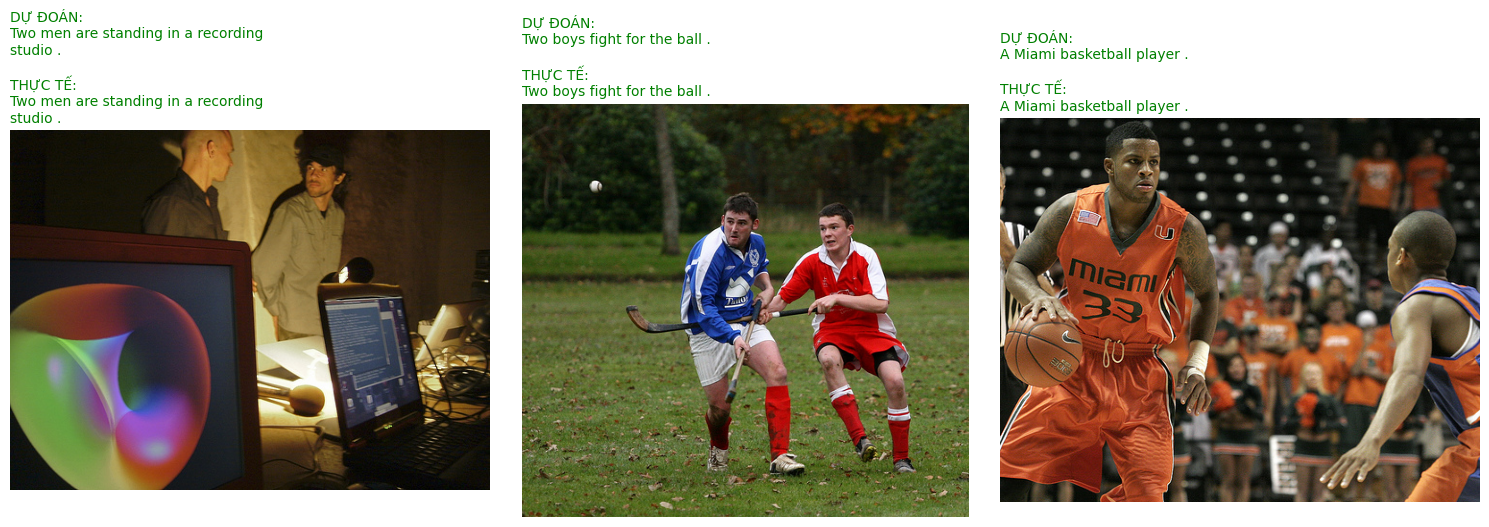

In [4]:
import matplotlib.pyplot as plt

def visualize_random_predictions(data_loader, model_manager, num_images=3):
    """Bốc ngẫu nhiên N ảnh, chạy dự báo và vẽ lên màn hình matplotlib"""
    if not data_loader.unique_images:
        return
        
    # Bốc ngẫu nhiên N ảnh từ tập dữ liệu
    sample_images = random.sample(data_loader.unique_images, num_images)
    
    # Thiết lập khung vẽ (1 hàng, N cột)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    if num_images == 1:
        axes = [axes] # Xử lý lỗi nếu chỉ in 1 ảnh
        
    for i, img_filename in enumerate(sample_images):
        img_path = os.path.join(data_loader.img_dir, img_filename)
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            logger.warning(f"Lỗi đọc ảnh {img_filename}")
            continue
            
        # Lấy câu đúng và danh sách câu sai
        correct_cap, candidates = data_loader.get_candidate_captions(img_filename)
        
        # Dự báo
        best_idx = model_manager.compute_similarity(image, candidates)
        predicted_cap = candidates[best_idx]
        
        # Cắt ngắn text nếu quá dài để hiển thị cho đẹp
        def wrap_text(text, width=40):
            import textwrap
            return "\n".join(textwrap.wrap(text, width=width))
        
        # Vẽ ảnh
        axes[i].imshow(image)
        axes[i].axis('off')
        
        # Cài đặt tiêu đề (Đúng -> Xanh, Sai -> Đỏ)
        color = "green" if correct_cap == predicted_cap else "red"
        title = f"DỰ ĐOÁN:\n{wrap_text(predicted_cap)}\n\nTHỰC TẾ:\n{wrap_text(correct_cap)}"
        axes[i].set_title(title, color=color, fontsize=10, loc='left')

    plt.tight_layout()
    plt.show()

# Thực thi hàm trực quan hóa
print("\n[INFO] Đang sinh kết quả trực quan...")
visualize_random_predictions(data_pipeline, clip_engine, num_images=3)